In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data

In [2]:
df = pd.read_csv('cleaned_data.csv')
df['genres'] = df['genres'].apply(lambda x: x.split(';') if pd.notnull(x) else [])
df.head()

,url,title,genres,description
0,https://www.filmweb.pl/film/Zielona+mila-1999-862,Zielona mila,[Dramat],Rok 1935. Paul Edgecombe (Tom Hanks) jest jedn...
1,https://www.filmweb.pl/film/Skazani+na+Shawsha...,Skazani na Shawshank,[Dramat],Film nakręcony na podstawie książki mistrza ho...
2,https://www.filmweb.pl/film/Forrest+Gump-1994-998,Forrest Gump,"[Dramat, Komedia]","""Forrest Gump"" to romantyczna historia, w któr..."
3,https://www.filmweb.pl/film/Leon+zawodowiec-19...,Leon zawodowiec,"[Dramat, Kryminał]",Leon (Jean Reno) jest płatnym zabójcą. W niczy...
4,https://www.filmweb.pl/film/Requiem+dla+snu-20...,Requiem dla snu,[Dramat],Wstrząsająca opowieść o czwórce bohaterów z Br...


## Genres

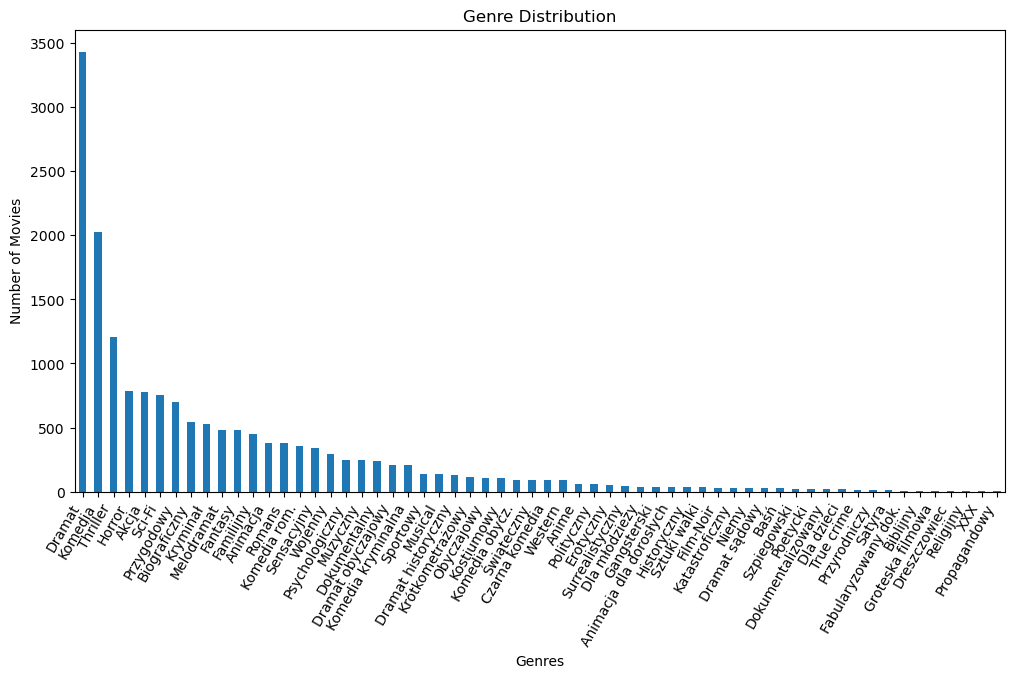

In [3]:
genre_count = df['genres'].explode().value_counts()

genre_count.plot(kind='bar', title='Genre Distribution', ylabel='Number of Movies', xlabel='Genres', figsize=(12, 6))
plt.xticks(rotation=60, ha='right')
# plt.savefig('genre_distribution.png')
plt.show()

In [4]:
print(genre_count)

genres
Dramat                    3432
Komedia                   2025
Thriller                  1205
Horror                     788
Akcja                      781
Sci-Fi                     757
Przygodowy                 699
Biograficzny               540
Kryminał                   529
Melodramat                 482
Fantasy                    480
Familijny                  446
Animacja                   382
Romans                     376
Komedia rom.               355
Sensacyjny                 341
Wojenny                    292
Psychologiczny             247
Muzyczny                   244
Dokumentalny               241
Dramat obyczajowy          210
Komedia kryminalna         207
Sportowy                   140
Musical                    138
Dramat historyczny         127
Krótkometrażowy            117
Obyczajowy                 109
Kostiumowy                 104
Komedia obycz.              94
Świąteczny                  94
Czarna komedia              91
Western                     87
A

In [5]:
num_unique_genres = genre_count.shape[0]
print(f'Number of unique genres: {num_unique_genres}')

Number of unique genres: 60


In [6]:
average_genres_per_movie = genre_count.sum() / df.shape[0]
print(f'Average number of genres per movie: {average_genres_per_movie:.2f}')

Average number of genres per movie: 1.77


In [7]:
genres = df['genres'].explode().unique()
list(genres)

['Dramat',
 'Komedia',
 'Kryminał',
 'Sci-Fi',
 'Akcja',
 'Thriller',
 'Dramat historyczny',
 'Gangsterski',
 'Przygodowy',
 'Fantasy',
 'Familijny',
 'Dramat obyczajowy',
 'Biograficzny',
 'Kostiumowy',
 'Horror',
 'Melodramat',
 'Psychologiczny',
 'Dreszczowiec',
 'Animacja',
 'Polityczny',
 'Erotyczny',
 'Komedia kryminalna',
 'Sportowy',
 'Wojenny',
 'Czarna komedia',
 'Musical',
 'Romans',
 'Dokumentalny',
 'Sensacyjny',
 'Western',
 'Komedia obycz.',
 'Historyczny',
 'Komedia rom.',
 'Krótkometrażowy',
 'Groteska filmowa',
 'Satyra',
 'Szpiegowski',
 'Świąteczny',
 'Muzyczny',
 'Surrealistyczny',
 'Anime',
 'Obyczajowy',
 'Poetycki',
 'Dla dzieci',
 'Sztuki walki',
 'Dla młodzieży',
 'Biblijny',
 'Niemy',
 'Katastroficzny',
 'Dramat sądowy',
 'Animacja dla dorosłych',
 'Baśń',
 'Film-Noir',
 'Dokumentalizowany',
 'Religijny',
 'Fabularyzowany dok.',
 'XXX',
 'True crime',
 'Przyrodniczy',
 'Propagandowy']

## Descriptions

In [8]:
df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))
average_word_count = df['description_word_count'].mean()
print(f'Average word count in descriptions: {average_word_count:.2f}')
print(f'Maximum word count in descriptions: {df["description_word_count"].max()}')
print(f'Minimum word count in descriptions: {df["description_word_count"].min()}')

Average word count in descriptions: 81.74
Maximum word count in descriptions: 555
Minimum word count in descriptions: 14


# Model

In [20]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [10]:
class MoviesDataset(torch.utils.data.Dataset):
	def __init__(self, encodings, labels):
		self.encodings = encodings
		self.labels = labels

	def __getitem__(self, idx):
		return {
			'input_ids': torch.tensor(self.encodings['input_ids'][idx], dtype=torch.long),
			'attention_mask': torch.tensor(self.encodings['attention_mask'][idx], dtype=torch.long),
			'labels': torch.tensor(self.labels[idx], dtype=torch.float)
		}
	
	def __len__(self):
		return len(self.labels)

In [11]:
def build_label_mappings(df: pd.DataFrame) -> tuple[dict, dict]:
	all_genres = df['genres'].explode().unique()
	genre_to_idx = {genre: idx for idx, genre in enumerate(all_genres)}
	index_to_genre = {idx: genre for genre, idx in genre_to_idx.items()}
	return genre_to_idx, index_to_genre

def build_dataset(df: pd.DataFrame, genre_to_idx: dict, tokenizer_name: str="allegro/herbert-base-cased", max_length: int=512) -> MoviesDataset:
	num_labels = len(genre_to_idx)

	# Multi-hot encoding of genres
	def encode_genres(genres_list):
		vec = np.zeros(num_labels, dtype=int)
		for genre in genres_list:
			if genre in genre_to_idx:
				vec[genre_to_idx[genre]] = 1
		return vec
	labels = df['genres'].apply(encode_genres).tolist()

	# Tokenization
	tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
	encodings = tokenizer(
		df['description'].tolist(),
		padding=True,
		truncation=True,
		max_length=max_length
	)

	dataset = MoviesDataset(encodings, labels)

	return dataset

In [12]:
class HerBERTMultiLabelClassifier(torch.nn.Module):
	def __init__(self, num_labels: int, model_name: str="allegro/herbert-base-cased", dropout: float=0.25):
		super().__init__()
		self.encoder = AutoModel.from_pretrained(model_name)
		hidden_size = self.encoder.config.hidden_size

		self.classifier = torch.nn.Sequential(
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size, hidden_size // 2),
			torch.nn.ReLU(),
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size // 2, num_labels)
		)

	def forward(self, input_ids, attention_mask):
		outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
		cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token output
		logits = self.classifier(cls_output)
		return logits

In [49]:
def train_model(
	model: torch.nn.Module,
	train_loader: torch.utils.data.DataLoader,
	val_loader: torch.utils.data.DataLoader,
	num_epochs: int,
	learning_rate: float = 1e-4,
	device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
	threshold: float = 0.25
):
	model.to(device)
	optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
	criterion = torch.nn.BCEWithLogitsLoss()

	for epoch in range(num_epochs):
		# Training
		model.train()
		total_loss = 0
		for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training'):
			optimizer.zero_grad()
			input_ids = batch['input_ids'].to(device)
			attention_mask = batch['attention_mask'].to(device)
			labels = batch['labels'].to(device).float()

			logits = model(input_ids=input_ids, attention_mask=attention_mask)
			loss = criterion(logits, labels)
			loss.backward()
			optimizer.step()

			total_loss += loss.item()

		avg_loss = total_loss / len(train_loader)

		# Validation
		model.eval()
		val_loss = 0
		all_labels = []
		all_preds = []
		with torch.no_grad():
			for batch in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Validation'):
				input_ids = batch['input_ids'].to(device)
				attention_mask = batch['attention_mask'].to(device)
				labels = batch['labels'].to(device) # .float() ?

				logits = model(input_ids=input_ids, attention_mask=attention_mask)
				loss = criterion(logits, labels) # .float() ?
				val_loss += loss.item()

				probabilities = torch.sigmoid(logits)
				predictions = (probabilities > threshold).int()

				all_labels.append(labels.cpu().int())
				all_preds.append(predictions.cpu())

		avg_val_loss = val_loss / len(val_loader)

		all_labels = torch.cat(all_labels)
		all_preds = torch.cat(all_preds)

		label_wise_accuracy = (all_labels == all_preds).float().mean().item() # label-wise accuracy
		sample_wise_accuracy = ((all_labels == all_preds).all(dim=1)).float().mean().item() # sample-wise accuracy
		f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) # F1 score
		f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0) # Micro F1 score

		print(f'Epoch {epoch + 1}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {label_wise_accuracy:.4f}, Sample-wise Acc: {sample_wise_accuracy:.4f}, F1 Score: {f1:.4f}, Micro F1 Score: {f1_micro:.4f}')

In [14]:
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

genre_to_idx, idx_to_genre = build_label_mappings(df)
train_dataset = build_dataset(df_train, genre_to_idx)
validation_dataset = build_dataset(df_val, genre_to_idx)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

In [ ]:
num_labels = len(genre_to_idx)
model = HerBERTMultiLabelClassifier(num_labels=num_labels)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
	val_loader=validation_loader,
	num_epochs=5
)

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/5 Validation: 100%|██████████| 119/119 [00:47<00:00,  2.52it/s]


Epoch 1, Train Loss: 0.1267, Val Loss: 0.0938, Val Accuracy: 0.9706


Epoch 2/5 Validation: 100%|██████████| 119/119 [00:49<00:00,  2.41it/s]


Epoch 2, Train Loss: 0.0999, Val Loss: 0.1044, Val Accuracy: 0.9703


Epoch 3/5 Training:  72%|███████▏  | 343/476 [39:58<21:43,  9.80s/it]

In [ ]:
# save the model
torch.save(trained_model.state_dict(), 'herbert_multilabel_classifier.pth')

In [ ]:
# TODO: Class weights balancing for imbalanced dataset
# TODO: Early stopping mechanism? 
# TODO: Try freezing HerBERT layers
# TODO: learn more about gradient clipping

### Weighted loss

In [16]:
weights = genre_count.min() / genre_count
print(weights)

genres
Dramat                    0.000583
Komedia                   0.000988
Thriller                  0.001660
Horror                    0.002538
Akcja                     0.002561
Sci-Fi                    0.002642
Przygodowy                0.002861
Biograficzny              0.003704
Kryminał                  0.003781
Melodramat                0.004149
Fantasy                   0.004167
Familijny                 0.004484
Animacja                  0.005236
Romans                    0.005319
Komedia rom.              0.005634
Sensacyjny                0.005865
Wojenny                   0.006849
Psychologiczny            0.008097
Muzyczny                  0.008197
Dokumentalny              0.008299
Dramat obyczajowy         0.009524
Komedia kryminalna        0.009662
Sportowy                  0.014286
Musical                   0.014493
Dramat historyczny        0.015748
Krótkometrażowy           0.017094
Obyczajowy                0.018349
Kostiumowy                0.019231
Komedia obycz

In [17]:
def train_model_with_weighted_loss(
	model: torch.nn.Module,
	train_loader: torch.utils.data.DataLoader,
	val_loader: torch.utils.data.DataLoader,
	num_epochs: int,
	learning_rate: float = 1e-4,
	device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
):
	model.to(device)
	optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
	pos_weight = torch.tensor(weights.values, dtype=torch.float32).to(device)
	criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

	for epoch in range(num_epochs):
		# Training
		model.train()
		total_loss = 0
		for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training'):
			optimizer.zero_grad()
			input_ids = batch['input_ids'].to(device)
			attention_mask = batch['attention_mask'].to(device)
			labels = batch['labels'].to(device).float()

			logits = model(input_ids=input_ids, attention_mask=attention_mask)
			loss = criterion(logits, labels)
			loss.backward()
			optimizer.step()

			total_loss += loss.item()

		avg_loss = total_loss / len(train_loader)

		# Validation
		model.eval()
		val_loss = 0
		all_labels = []
		all_preds = []
		with torch.no_grad():
			for batch in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Validation'):
				input_ids = batch['input_ids'].to(device)
				attention_mask = batch['attention_mask'].to(device)
				labels = batch['labels'].to(device) # .float() ?

				logits = model(input_ids=input_ids, attention_mask=attention_mask)
				loss = criterion(logits, labels) # .float() ?
				val_loss += loss.item()

				probabilities = torch.sigmoid(logits)
				predictions = (probabilities > 0.5).int()

				all_labels.append(labels.cpu())
				all_preds.append(predictions.cpu())

		avg_val_loss = val_loss / len(val_loader)

		all_labels = torch.cat(all_labels)
		all_preds = torch.cat(all_preds)

		accuracy = (all_labels == all_preds).float().mean().item()

		print(f'Epoch {epoch + 1}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {accuracy:.4f}')

In [ ]:
num_labels = len(genre_to_idx)
model = HerBERTMultiLabelClassifier(num_labels=num_labels)

trained_model = train_model_with_weighted_loss(
    model=model,
    train_loader=train_loader,
	val_loader=validation_loader,
	num_epochs=5
)

### HerBERT parameter freeze

In [18]:
class HerBERTFrozenMultiLabelClassifier(torch.nn.Module):
	def __init__(self, num_labels: int, model_name: str="allegro/herbert-base-cased", dropout: float=0.25):
		super().__init__()
		self.encoder =self.create_encoder(model_name)
		hidden_size = self.encoder.config.hidden_size

		self.classifier = torch.nn.Sequential(
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size, hidden_size // 2),
			torch.nn.ReLU(),
			torch.nn.Dropout(dropout),
			torch.nn.Linear(hidden_size // 2, num_labels)
		)
		
	def create_encoder(self, model_name):
		encoder = AutoModel.from_pretrained(model_name)
		for param in encoder.parameters():
			param.requires_grad = False
		return encoder
    

	def forward(self, input_ids, attention_mask):
		outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
		cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token output
		logits = self.classifier(cls_output)
		return logits

In [48]:
num_labels = len(genre_to_idx)
frozen_model = HerBERTFrozenMultiLabelClassifier(num_labels=num_labels)

trained_model = train_model(
    model=frozen_model,
    train_loader=train_loader,
	val_loader=validation_loader,
	num_epochs=5
)

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/5 Validation: 100%|██████████| 119/119 [00:34<00:00,  3.44it/s]


Epoch 1, Train Loss: 0.1628, Val Loss: 0.1027, Val Accuracy: 0.9659, Sample-wise Acc: 0.1029, F1 Score: 0.0090, Micro F1 Score: 0.2644


Epoch 2/5 Validation: 100%|██████████| 119/119 [00:33<00:00,  3.57it/s]



Epoch 2, Train Loss: 0.1048, Val Loss: 0.1019, Val Accuracy: 0.9660, Sample-wise Acc: 0.1035, F1 Score: 0.0103, Micro F1 Score: 0.2697


Epoch 3/5 Validation: 100%|██████████| 119/119 [00:35<00:00,  3.35it/s]


Epoch 3, Train Loss: 0.1035, Val Loss: 0.1010, Val Accuracy: 0.9659, Sample-wise Acc: 0.1035, F1 Score: 0.0097, Micro F1 Score: 0.2671


Epoch 4/5 Validation: 100%|██████████| 119/119 [00:36<00:00,  3.29it/s]


Epoch 4, Train Loss: 0.1022, Val Loss: 0.1005, Val Accuracy: 0.9680, Sample-wise Acc: 0.0898, F1 Score: 0.0108, Micro F1 Score: 0.2516


Epoch 5/5 Validation: 100%|██████████| 119/119 [00:34<00:00,  3.48it/s]

Epoch 5, Train Loss: 0.1012, Val Loss: 0.0994, Val Accuracy: 0.9648, Sample-wise Acc: 0.0861, F1 Score: 0.0164, Micro F1 Score: 0.3001


In [52]:
# save model
torch.save(frozen_model.state_dict(), 'model.pth')


## Baseline Models

TF-IDF + Logistic Regression jako prosty baseline do porównania z modelami HerBERT.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, f1_score, hamming_loss, jaccard_score

In [42]:
def train_tfidf_baseline(df_train: pd.DataFrame, df_val: pd.DataFrame, genre_to_idx: dict, max_features: int = 5000, max_iter: int = 100):
	"""
	Train TF-IDF + Logistic Regression baseline model for multi-label classification.
	
	Args:
		df_train: Training dataframe with 'description' and 'genres' columns
		df_val: Validation dataframe
		genre_to_idx: Dictionary mapping genre names to indices
		max_features: Maximum number of TF-IDF features
		max_iter: Maximum iterations for LogisticRegression
	
	Returns:
		vectorizer, model, metrics_dict
	"""
	num_labels = len(genre_to_idx)
	
	# Encode genres to multi-hot vectors
	def encode_genres(genres_list):
		vec = np.zeros(num_labels, dtype=int)
		for genre in genres_list:
			if genre in genre_to_idx:
				vec[genre_to_idx[genre]] = 1
		return vec
	
	y_train = np.array(df_train['genres'].apply(encode_genres).tolist())
	y_val = np.array(df_val['genres'].apply(encode_genres).tolist())
	
	# TF-IDF Vectorization
	print("Creating TF-IDF features...")
	vectorizer = TfidfVectorizer(max_features=max_features, stop_words=None, ngram_range=(1, 2))
	X_train = vectorizer.fit_transform(df_train['description'].fillna(''))
	X_val = vectorizer.transform(df_val['description'].fillna(''))
	
	print(f"TF-IDF shape: {X_train.shape}")
	print(f"Training baseline model...")
	
	# Multi-label classifier (one LogisticRegression per label)
	base_clf = LogisticRegression(max_iter=max_iter, solver='lbfgs', random_state=42)
	model = MultiOutputClassifier(base_clf, n_jobs=-1)
	
	model.fit(X_train, y_train)
	
	# print("Evaluating on validation set...")
	y_pred = model.predict(X_val)
	
	# Calculate metrics
	label_wise_acc = accuracy_score(y_val.flatten(), y_pred.flatten())
	sample_wise_acc = accuracy_score(y_val, y_pred)
	f1_macro = f1_score(y_val, y_pred, average='macro', zero_division=0)
	f1_micro = f1_score(y_val, y_pred, average='micro', zero_division=0)
	hamming = hamming_loss(y_val, y_pred)
	jaccard = jaccard_score(y_val, y_pred, average='samples', zero_division=0)
	
	metrics = {
		'label_wise_accuracy': label_wise_acc,
		'sample_wise_accuracy': sample_wise_acc,
		'f1_macro': f1_macro,
		'f1_micro': f1_micro,
		'hamming_loss': hamming,
		'jaccard_samples': jaccard
	}
	
	print("\n=== TF-IDF Baseline Results ===")
	print(f"Label-wise Accuracy: {label_wise_acc:.4f}")
	print(f"Sample-wise Accuracy (Exact Match): {sample_wise_acc:.4f}")
	print(f"F1 Score (Macro): {f1_macro:.4f}")
	print(f"F1 Score (Micro): {f1_micro:.4f}")
	print(f"Hamming Loss: {hamming:.4f}")
	print(f"Jaccard Score (samples avg): {jaccard:.4f}")
	
	return vectorizer, model, metrics

In [43]:
# Train TF-IDF baseline model
tfidf_vectorizer, tfidf_model, tfidf_metrics = train_tfidf_baseline(
	df_train, 
	df_val, 
	genre_to_idx,
	max_features=10000,  # więcej features dla lepszej reprezentacji
	max_iter=200
)

Creating TF-IDF features...
TF-IDF shape: (7615, 10000)
Training baseline model...
TF-IDF shape: (7615, 10000)
Training baseline model...

=== TF-IDF Baseline Results ===
Label-wise Accuracy: 0.9713
Sample-wise Accuracy (Exact Match): 0.0452
F1 Score (Macro): 0.0101
F1 Score (Micro): 0.1217
Hamming Loss: 0.0287
Jaccard Score (samples avg): 0.0783

=== TF-IDF Baseline Results ===
Label-wise Accuracy: 0.9713
Sample-wise Accuracy (Exact Match): 0.0452
F1 Score (Macro): 0.0101
F1 Score (Micro): 0.1217
Hamming Loss: 0.0287
Jaccard Score (samples avg): 0.0783


In [44]:
def predict_genres_tfidf(text: str, vectorizer: TfidfVectorizer, model: MultiOutputClassifier, idx_to_genre: dict, threshold: float = 0.5):
	"""
	Predict genres for a given movie description using TF-IDF model.
	
	Args:
		text: Movie description (string)
		vectorizer: Fitted TfidfVectorizer
		model: Trained MultiOutputClassifier
		idx_to_genre: Dictionary mapping indices to genre names
		threshold: Probability threshold for classification
	
	Returns:
		List of predicted genre names
	"""
	X = vectorizer.transform([text])
	
	# Get probabilities for each label
	probas = np.array([clf.predict_proba(X)[:, 1] for clf in model.estimators_]).flatten()
	
	# Apply threshold
	predicted_indices = np.where(probas >= threshold)[0]
	predicted_genres = [idx_to_genre[idx] for idx in predicted_indices]
	
	return predicted_genres, probas

In [60]:
# Test predykcji na przykładzie z validation set
sample_idx = 5
sample_description = df_val.iloc[sample_idx]['description']
true_genres = df_val.iloc[sample_idx]['genres']

predicted_genres, probas = predict_genres_tfidf(
	sample_description, 
	tfidf_vectorizer, 
	tfidf_model, 
	idx_to_genre,
	threshold=0.2  # niższy próg dla multilabel
)

print("=== Example Prediction ===")
print(f"Description: {sample_description[:70]}...")
print(f"\nTrue genres: {true_genres}")
print(f"Predicted genres: {predicted_genres}")
print(f"\nTop 5 probabilities:")
top5_idx = np.argsort(probas)[-5:][::-1]
for idx in top5_idx:
	print(f"  {idx_to_genre[idx]}: {probas[idx]:.3f}")

=== Example Prediction ===
Description: Minęły trzy lata odkąd Austin Powers, agent specjalnej troski, stawił ...

True genres: ['Komedia', 'Akcja']
Predicted genres: ['Komedia', 'Akcja']

Top 5 probabilities:
  Komedia: 0.299
  Akcja: 0.233
  Dramat: 0.135
  Przygodowy: 0.129
  Sci-Fi: 0.127
